In [1]:
import pandas as pd
import glob
import os
import numpy as np
from scipy.optimize import minimize
from scipy.optimize import minimize_scalar
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

# === 1. Define folder path ===
folder_path = "/Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/HAISAdata2"

# === 2. Find all climate CSV files ===
all_files = glob.glob(os.path.join(folder_path, "climate-daily*.csv"))

if not all_files:
    raise FileNotFoundError(f"No files found matching pattern in: {folder_path}")

print(f"Found {len(all_files)} CSV files to merge.")

# === 3. Read and merge all CSVs ===
df_list = []
for f in all_files:
    print(f"Reading: {os.path.basename(f)}")
    df = pd.read_csv(f, low_memory=False)  # prevents DtypeWarning
    df_list.append(df)

merged_df = pd.concat(df_list, ignore_index=True)
print(f"Merged {len(df_list)} files. Shape: {merged_df.shape}")

# === 4. Keep only required columns ===
keep_cols = [
    "STATION_NAME",
    "LOCAL_DATE",
    "LOCAL_YEAR",
    "LOCAL_MONTH",
    "LOCAL_DAY",
    "TOTAL_PRECIPITATION"
]
merged_df = merged_df[keep_cols]

# === 5. Ensure LOCAL_YEAR is numeric and filter 1995–2024 ===
merged_df["LOCAL_YEAR"] = pd.to_numeric(merged_df["LOCAL_YEAR"], errors="coerce")
merged_df = merged_df[
    (merged_df["LOCAL_YEAR"] >= 1995) & (merged_df["LOCAL_YEAR"] <= 2024)
]

# === 6. Map STATION_NAME → RM ===
station_to_rm = {
    "ASSINIBOIA": 72,
    "BROADVIEW": 154,
    "ESTEVAN A": 5,
    "KINDERSLEY A": 290
}

merged_df["RMs"] = merged_df["STATION_NAME"].map(station_to_rm)

# === 7. Sort data by LOCAL_YEAR, LOCAL_MONTH, LOCAL_DAY, and RMs ===
merged_df = merged_df.sort_values(
    by=["LOCAL_YEAR", "LOCAL_MONTH", "LOCAL_DAY", "RMs"],
    ascending=[True, True, True, True]
).reset_index(drop=True)

print("Data sorted by year, month, day, and RM.")

# === 8. Save final output ===
output_file = os.path.join(folder_path, "climate-daily-merged-1995-2024-with-RMs.csv")
merged_df.to_csv(output_file, index=False)

# === 9. Done ===
print(f"\n Final sorted dataset saved to:\n{output_file}")
print(f"Shape: {merged_df.shape[0]} rows × {merged_df.shape[1]} columns\n")
print(merged_df.head(10))

Found 9 CSV files to merge.
Reading: climate-daily (2).csv
Reading: climate-daily (3).csv
Reading: climate-daily (4).csv
Reading: climate-daily.csv
Reading: climate-daily (8).csv
Reading: climate-daily (5).csv
Reading: climate-daily (6).csv
Reading: climate-daily (7).csv
Reading: climate-daily (1).csv
Merged 9 files. Shape: (87632, 36)
Data sorted by year, month, day, and RM.

 Final sorted dataset saved to:
/Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/HAISAdata2/climate-daily-merged-1995-2024-with-RMs.csv
Shape: 33557 rows × 7 columns

   STATION_NAME           LOCAL_DATE  LOCAL_YEAR  LOCAL_MONTH  LOCAL_DAY  \
0     ESTEVAN A  1995-01-01 00:00:00        1995            1          1   
1    ASSINIBOIA  1995-01-01 00:00:00        1995            1          1   
2     BROADVIEW  1995-01-01 00:00:00        1995            1          1   
3  KINDERSLEY A  1995-01-01 00:00:00        1995            1          1   
4     ESTEVAN A  1995-01-02 00:00:00        1995            1    

In [2]:
# handle missing precipitations sums not to break
merged_df["TOTAL_PRECIPITATION"] = merged_df["TOTAL_PRECIPITATION"].fillna(0)

# Group by RM, Year, and Month & sum daily precipitation
monthly_precip = (
    merged_df
    .groupby(["RMs", "LOCAL_YEAR", "LOCAL_MONTH"], as_index=False)
    ["TOTAL_PRECIPITATION"]
    .sum()
)

# Pivot so months become columns (Jan–Dec)
monthly_precip_pivot = monthly_precip.pivot_table(
    index=["RMs", "LOCAL_YEAR"],
    columns="LOCAL_MONTH",
    values="TOTAL_PRECIPITATION",
    fill_value=0
)

# Rename month columns for clarity
monthly_precip_pivot.columns = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

# Reset index to get a clean table
monthly_precip_pivot = monthly_precip_pivot.reset_index()
print(monthly_precip_pivot.tail())
print(monthly_precip_pivot.shape)

    RMs  LOCAL_YEAR   Jan   Feb   Mar   Apr   May    Jun   Jul   Aug   Sep  \
88  290        2020  10.8   9.6  11.6  15.0  17.8   89.8  87.6  15.0  26.2   
89  290        2021   9.2   2.0  16.8   5.8  32.4   36.8  16.2  76.0   3.4   
90  290        2022  21.0  15.6   9.8  15.8  10.8  102.4  58.5  12.2   7.6   
91  290        2023   3.8   7.8   8.2   5.4  10.3   32.6  27.0  27.7  15.0   
92  290        2024  11.4  17.4  10.3  37.7  62.7  127.4  22.4  27.7  35.4   

     Oct   Nov   Dec  
88   5.6  60.6   7.4  
89   2.0   7.2   7.8  
90  34.3  38.7  34.2  
91  10.3   4.6   3.6  
92   2.6  17.4  15.8  
(93, 14)


In [3]:
merged_df.groupby("RMs")["LOCAL_YEAR"].nunique()

RMs
5      30
72      3
154    30
290    30
Name: LOCAL_YEAR, dtype: int64

In [4]:
rm72_years = (
    merged_df[merged_df["RMs"] == 72][["RMs", "LOCAL_YEAR"]]
    .drop_duplicates()
    .sort_values("LOCAL_YEAR")
)

print(rm72_years)
print("Number of RM–Year combinations for RM 72:", rm72_years.shape[0])


      RMs  LOCAL_YEAR
1      72        1995
1461   72        1996
2925   72        1997
Number of RM–Year combinations for RM 72: 3


In [5]:
monthly_precip_pivot = monthly_precip_pivot[
    monthly_precip_pivot["RMs"] != 72
].reset_index(drop=True)

print(monthly_precip_pivot.shape)

(90, 14)


In [6]:
# load all initial data 
file_path = "/Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/results/climate-daily-merged-1995-2024-with-RMs.csv"
df = pd.read_csv(file_path)
df = df.drop(columns=["LOCAL_DATE"])

df.head()

,STATION_NAME,LOCAL_YEAR,LOCAL_MONTH,LOCAL_DAY,TOTAL_PRECIPITATION,RMs
0,CORONACH SPC,1995,1,1,0.0,3
1,VAL MARIE SOUTHEAST,1995,1,1,0.0,17
2,MANKOTA,1995,1,1,1.0,45
3,EASTEND CYPRESS (AUT),1995,1,1,NaN,49
4,WEYBURN,1995,1,1,0.0,67


In [7]:
# sum initial daily data into monthly data 
df["TOTAL_PRECIPITATION"] = df["TOTAL_PRECIPITATION"].fillna(0)

monthly_precip = (
    df
    .groupby(["RMs", "LOCAL_YEAR", "LOCAL_MONTH"], as_index=False)
    ["TOTAL_PRECIPITATION"]
    .sum()
)

monthly_precip_results = (
    monthly_precip
    .pivot_table(
        index=["RMs", "LOCAL_YEAR"],
        columns="LOCAL_MONTH",
        values="TOTAL_PRECIPITATION",
        fill_value=0
    )
    .reindex(columns=range(1, 13), fill_value=0)
)

monthly_precip_results.columns = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

monthly_precip_results = monthly_precip_results.reset_index()

print(monthly_precip_results.shape)
monthly_precip_results.groupby("RMs")["LOCAL_YEAR"].nunique()

(1016, 14)


RMs
3      30
17     30
45     27
49     30
67     30
72     30
76     30
111    30
113    30
124    30
137    30
154    30
156    30
158    30
187    30
191    29
197    30
217    30
225    30
226    30
231    30
247    30
254    30
284    30
321    30
338    30
339    30
342    30
344    30
376    30
471    30
488    30
496    30
501    30
Name: LOCAL_YEAR, dtype: int64

In [19]:
# Remove RM 45 and RM 191
monthly_precip_results = monthly_precip_results[
    ~monthly_precip_results["RMs"].isin([45, 191])
].reset_index(drop=True)

# Verify
print(monthly_precip_results["RMs"].value_counts())
print("Shape after dropping RMs 45 and 191:", monthly_precip_results.shape)


RMs
3      30
17     30
496    30
488    30
471    30
376    30
344    30
342    30
339    30
338    30
321    30
284    30
254    30
247    30
231    30
226    30
225    30
217    30
197    30
187    30
158    30
156    30
154    30
137    30
124    30
113    30
111    30
76     30
72     30
67     30
49     30
501    30
Name: count, dtype: int64
Shape after dropping RMs 45 and 191: (960, 14)


In [8]:
# Vertically combine the two DataFrames
monthly_RMs = pd.concat(
    [monthly_precip_results, monthly_precip_pivot],
    ignore_index=True
)

# Sort by RM and year
monthly_RMs = monthly_RMs.sort_values(
    by=["RMs", "LOCAL_YEAR"]
).reset_index(drop=True)

# Verify
print(monthly_RMs.shape)
print(monthly_RMs.tail())

(1106, 14)
      RMs  LOCAL_YEAR   Jan   Feb   Mar   Apr   May    Jun    Jul   Aug   Sep  \
1101  501        2020  16.2   9.6  29.8   7.6  45.4   85.6  101.0  79.2   6.4   
1102  501        2021  14.2   1.4   6.6   0.0  51.0   50.4   11.0  25.6  10.6   
1103  501        2022  42.4  19.2  25.6  13.0  49.0  157.0   47.4  45.2   6.6   
1104  501        2023   9.8   7.2   5.2  14.6  10.4  101.6   34.2  61.6  25.8   
1105  501        2024  17.6  23.0  15.0  15.4  44.4   40.2   27.6  81.8  39.4   

       Oct   Nov   Dec  
1101  12.4  27.4   8.2  
1102  34.8  25.2  19.4  
1103   1.4  27.6  28.2  
1104   8.0   5.0   0.6  
1105   4.0  35.4  18.4  


In [20]:
# --- Define month columns ---
month_cols = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
              "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# --- Filter years just to be explicit ---
monthly_filtered = monthly_RMs[
    monthly_RMs["LOCAL_YEAR"].between(1995, 2024)
]

# --- Average monthly rainfall by RM ---
monthly_avg_rm = (
    monthly_filtered
    .groupby("RMs")[month_cols]
    .mean()
    .reset_index()
)

print(monthly_avg_rm.head())

   RMs        Jan        Feb        Mar        Apr        May        Jun  \
0    3  14.073333  12.163333  16.143333  21.680000  55.040000  66.890000   
1    5  15.080000  13.016667  15.610000  22.460000  66.336667  76.180000   
2   17  10.053333   7.860000  14.466667  26.026667  47.313333  59.336667   
3   45  11.533333   8.000000  12.688889  20.966667  46.885185  58.303704   
4   49   6.593333   5.350000   8.880000  19.956667  43.513333  61.740000   

         Jul        Aug        Sep        Oct        Nov        Dec  
0  45.483333  34.793333  25.236667  22.220000  13.156667  14.603333  
1  53.333333  43.640000  38.256667  28.246667  16.506667  16.346667  
2  40.236667  36.466667  29.016667  20.256667  15.170000  13.210000  
3  30.188889  28.800000  28.692593  21.088889  12.951852  11.855556  
4  34.926667  31.200000  30.856667  17.306667  10.340000   9.596667  


In [21]:
# --- Convert to long format ---
monthly_avg_long = monthly_avg_rm.melt(
    id_vars="RMs",
    value_vars=month_cols,
    var_name="Month",
    value_name="Avg_Rainfall"
)

# Ensure month order
monthly_avg_long["Month"] = pd.Categorical(
    monthly_avg_long["Month"],
    categories=month_cols,
    ordered=True
)

monthly_avg_long = monthly_avg_long.sort_values(["RMs", "Month"])

print(monthly_avg_long.head())

     RMs Month  Avg_Rainfall
0      3   Jan     14.073333
36     3   Feb     12.163333
72     3   Mar     16.143333
108    3   Apr     21.680000
144    3   May     55.040000


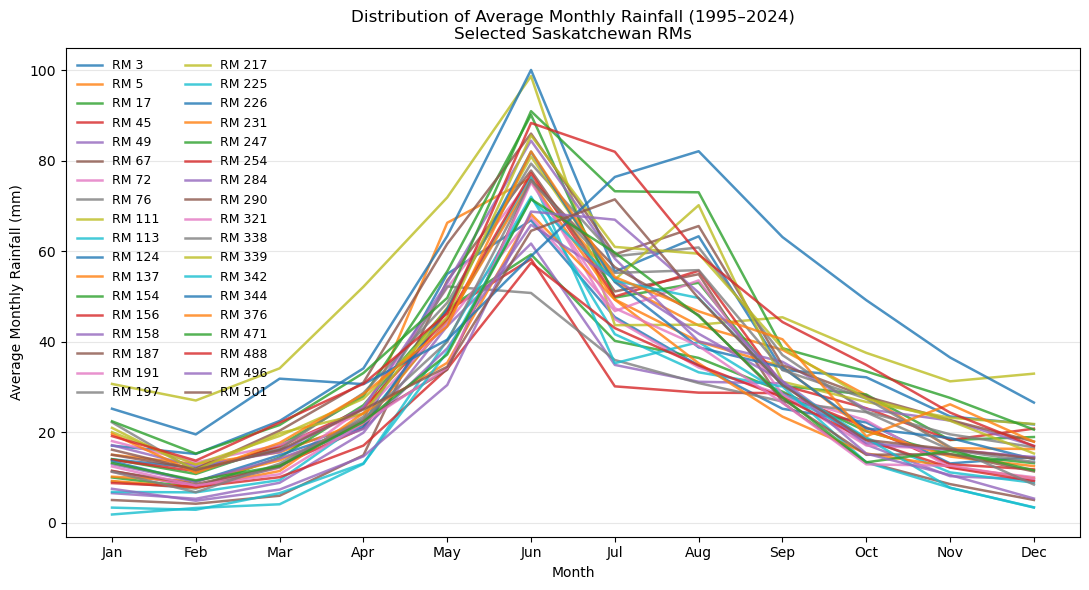

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 6))

for rm in monthly_avg_rm["RMs"]:
    rm_data = monthly_avg_long[monthly_avg_long["RMs"] == rm]
    plt.plot(
        rm_data["Month"],
        rm_data["Avg_Rainfall"],
        linewidth=1.8,
        alpha=0.8,
        label=f"RM {rm}"
    )

plt.xlabel("Month")
plt.ylabel("Average Monthly Rainfall (mm)")
plt.title("Distribution of Average Monthly Rainfall (1995–2024)\nSelected Saskatchewan RMs")

plt.grid(axis="y", alpha=0.3)
plt.legend(ncol=2, fontsize=9, frameon=False)
plt.tight_layout()

plt.show()

In [9]:
# List months in correct order
month_cols = ['Jan','Feb','Mar','Apr','May','Jun',
              'Jul','Aug','Sep','Oct','Nov','Dec']

periods = {}

# Only 1, 2, and 3 month consecutive windows
for window in [1, 2, 3]:
    for start in range(len(month_cols) - window + 1):
        period_months = month_cols[start:start + window]
        period_name = "_".join(period_months)
        periods[period_name] = period_months

periods

{'Jan': ['Jan'],
 'Feb': ['Feb'],
 'Mar': ['Mar'],
 'Apr': ['Apr'],
 'May': ['May'],
 'Jun': ['Jun'],
 'Jul': ['Jul'],
 'Aug': ['Aug'],
 'Sep': ['Sep'],
 'Oct': ['Oct'],
 'Nov': ['Nov'],
 'Dec': ['Dec'],
 'Jan_Feb': ['Jan', 'Feb'],
 'Feb_Mar': ['Feb', 'Mar'],
 'Mar_Apr': ['Mar', 'Apr'],
 'Apr_May': ['Apr', 'May'],
 'May_Jun': ['May', 'Jun'],
 'Jun_Jul': ['Jun', 'Jul'],
 'Jul_Aug': ['Jul', 'Aug'],
 'Aug_Sep': ['Aug', 'Sep'],
 'Sep_Oct': ['Sep', 'Oct'],
 'Oct_Nov': ['Oct', 'Nov'],
 'Nov_Dec': ['Nov', 'Dec'],
 'Jan_Feb_Mar': ['Jan', 'Feb', 'Mar'],
 'Feb_Mar_Apr': ['Feb', 'Mar', 'Apr'],
 'Mar_Apr_May': ['Mar', 'Apr', 'May'],
 'Apr_May_Jun': ['Apr', 'May', 'Jun'],
 'May_Jun_Jul': ['May', 'Jun', 'Jul'],
 'Jun_Jul_Aug': ['Jun', 'Jul', 'Aug'],
 'Jul_Aug_Sep': ['Jul', 'Aug', 'Sep'],
 'Aug_Sep_Oct': ['Aug', 'Sep', 'Oct'],
 'Sep_Oct_Nov': ['Sep', 'Oct', 'Nov'],
 'Oct_Nov_Dec': ['Oct', 'Nov', 'Dec']}

In [10]:
CR = monthly_RMs.copy()
for period_name, months in periods.items():
    CR[period_name] = CR[months].sum(axis=1)
# Define folder and output file path
output_folder = "/Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/results"
output_file = os.path.join(output_folder, "3window_cumulative_rainfall.csv")

# Save CR dataframe
CR.to_csv(output_file, index=False)

print(f"Cumulative rainfall dataset saved successfully:\n{output_file}")


Cumulative rainfall dataset saved successfully:
/Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/results/3window_cumulative_rainfall.csv


In [11]:
# --- Step 1: Load the Canola yield dataset ---
file1_path = "/Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/RM-Canola-1992_2024.csv"
df1 = pd.read_csv(file1_path)

# --- Step 2: Keep only needed columns ---
df1 = df1[['Year', 'RM', 'Canola']]

# --- Step 3: Filter by RM list from monthly_RMs and Year range 1995–2024 ---
rm_list = monthly_RMs['RMs'].unique()  # all RMs in monthly data

yield_filtered_all = df1[
    (df1['RM'].isin(rm_list)) &
    (df1['Year'].between(1995, 2024))
].reset_index(drop=True)

# --- Step 4: Optionally remove rows with missing Canola values ---
yield_filtered_all = yield_filtered_all.dropna(subset=['Canola']).reset_index(drop=True)

# --- Step 5: Define output path and save ---
output_folder = "/Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/results"
output_file = os.path.join(output_folder, "RM_canola_yield_all_RMs_1995_2024.csv")

yield_filtered_all.to_csv(output_file, index=False)

# --- Step 6: Print info ---
print(f"Filtered Canola dataset saved successfully to:\n{output_file}")
print(f"Shape: {yield_filtered_all.shape[0]} rows × {yield_filtered_all.shape[1]} columns")
print(yield_filtered_all.head())

Filtered Canola dataset saved successfully to:
/Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/results/RM_canola_yield_all_RMs_1995_2024.csv
Shape: 979 rows × 3 columns
   Year  RM  Canola
0  1995   3    18.8
1  1996   3    24.1
2  1997   3    16.6
3  1998   3    20.5
4  1999   3    20.3


In [12]:
# --- Summary statistics for Canola yield ---
canola_stats = {
    "Minimum": yield_filtered_all["Canola"].min(),
    "Maximum": yield_filtered_all["Canola"].max(),
    "Average": yield_filtered_all["Canola"].mean(),
    "Median": yield_filtered_all["Canola"].median(),
    "Standard Deviation": yield_filtered_all["Canola"].std()
}

# Convert to DataFrame for nice display
canola_summary = pd.DataFrame(canola_stats, index=["Yield (Bu/Ac)"])

print(canola_summary)

               Minimum  Maximum   Average  Median  Standard Deviation
Yield (Bu/Ac)      3.3     55.6  28.02998    27.6            9.793568


In [17]:
# --- Aggregate to annual Canola yield (SUM over RMs) ---
annual_canola = (
    yield_filtered_all
    .groupby("Year", as_index=False)["Canola"]
    .sum()
    .rename(columns={"Canola": "Canola_annual"})
)

print(annual_canola.head())

   Year  Canola_annual
0  1995          678.0
1  1996          736.6
2  1997          625.3
3  1998          707.0
4  1999          869.6


In [18]:
from sklearn.linear_model import LinearRegression
import numpy as np

# --- Prepare variables ---
X = annual_canola["Year"].values.reshape(-1, 1)
y = annual_canola["Canola_annual"].values

# --- Fit trend ---
model = LinearRegression()
model.fit(X, y)

# Trend and de-trended series
annual_canola["Canola_trend"] = model.predict(X)
annual_canola["Canola_detrended"] = (
    annual_canola["Canola_annual"] - annual_canola["Canola_trend"]
)

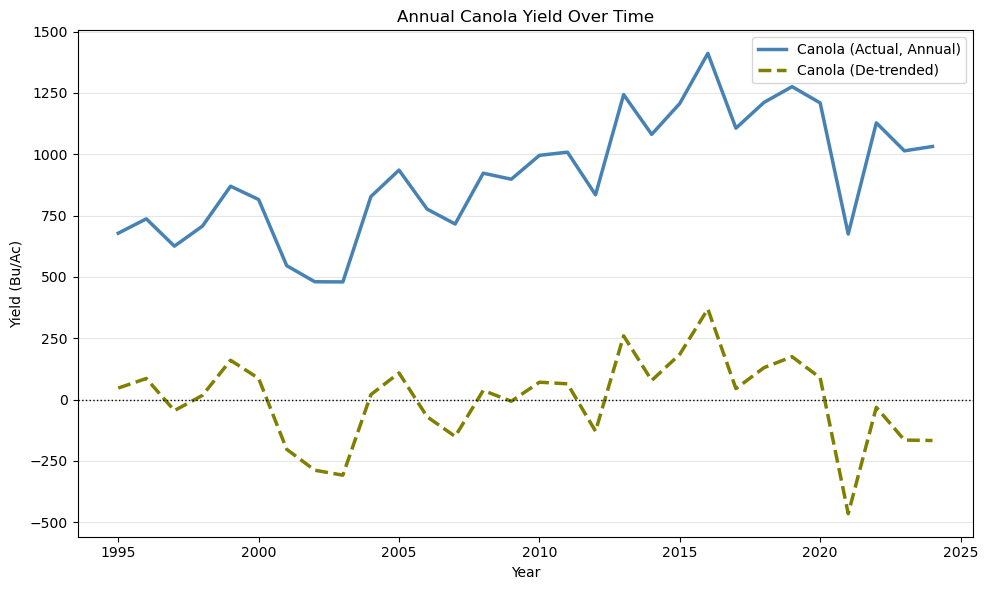

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Actual annual Canola (summed over RMs)
plt.plot(
    annual_canola["Year"],
    annual_canola["Canola_annual"],
    color="steelblue",
    linewidth=2.5,
    label="Canola (Actual, Annual)"
)

# De-trended Canola
plt.plot(
    annual_canola["Year"],
    annual_canola["Canola_detrended"],
    color="olive",
    linewidth=2.5,
    linestyle="--",
    label="Canola (De-trended)"
)

# Zero line for detrended series
plt.axhline(0, color="black", linestyle=":", linewidth=1)

plt.xlabel("Year")
plt.ylabel("Yield (Bu/Ac)")
plt.title("Annual Canola Yield Over Time")

plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

In [12]:
# Merge on RMs and Year (LOCAL_YEAR in CR, Year in yield)
merged = CR.merge(
    yield_filtered_all,
    left_on=['RMs', 'LOCAL_YEAR'],
    right_on=['RM', 'Year'],
    how='inner'   # only keep rows with both CR and yield
)

# Optional: drop duplicate RM/Year columns
merged = merged.drop(columns=['RM', 'Year'])
print(merged.tail())

      RMs  LOCAL_YEAR   Jan   Feb   Mar   Apr   May    Jun    Jul   Aug  ...  \
1001  501        2020  16.2   9.6  29.8   7.6  45.4   85.6  101.0  79.2  ...   
1002  501        2021  14.2   1.4   6.6   0.0  51.0   50.4   11.0  25.6  ...   
1003  501        2022  42.4  19.2  25.6  13.0  49.0  157.0   47.4  45.2  ...   
1004  501        2023   9.8   7.2   5.2  14.6  10.4  101.6   34.2  61.6  ...   
1005  501        2024  17.6  23.0  15.0  15.4  44.4   40.2   27.6  81.8  ...   

      Feb_Mar_Apr  Mar_Apr_May  Apr_May_Jun  May_Jun_Jul  Jun_Jul_Aug  \
1001         47.0         82.8        138.6        232.0        265.8   
1002          8.0         57.6        101.4        112.4         87.0   
1003         57.8         87.6        219.0        253.4        249.6   
1004         27.0         30.2        126.6        146.2        197.4   
1005         53.4         74.8        100.0        112.2        149.6   

      Jul_Aug_Sep  Aug_Sep_Oct  Sep_Oct_Nov  Oct_Nov_Dec  Canola  
1001        1

In [13]:
# Define output path
output_dir = "/Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/results/"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "final_data.csv")
# Save the data
merged.to_csv(output_path, index=False)

print("Saved file to:", output_path)
print(merged.tail())

Saved file to: /Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/results/final_data.csv
      RMs  LOCAL_YEAR   Jan   Feb   Mar   Apr   May    Jun    Jul   Aug  ...  \
1001  501        2020  16.2   9.6  29.8   7.6  45.4   85.6  101.0  79.2  ...   
1002  501        2021  14.2   1.4   6.6   0.0  51.0   50.4   11.0  25.6  ...   
1003  501        2022  42.4  19.2  25.6  13.0  49.0  157.0   47.4  45.2  ...   
1004  501        2023   9.8   7.2   5.2  14.6  10.4  101.6   34.2  61.6  ...   
1005  501        2024  17.6  23.0  15.0  15.4  44.4   40.2   27.6  81.8  ...   

      Feb_Mar_Apr  Mar_Apr_May  Apr_May_Jun  May_Jun_Jul  Jun_Jul_Aug  \
1001         47.0         82.8        138.6        232.0        265.8   
1002          8.0         57.6        101.4        112.4         87.0   
1003         57.8         87.6        219.0        253.4        249.6   
1004         27.0         30.2        126.6        146.2        197.4   
1005         53.4         74.8        100.0        112.2   

In [14]:
# --- 1. Define CR columns (1-, 2-, 3-month windows) ---
# 1-month
cr_1m = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# 2-month windows: columns with exactly 1 underscore
cr_2m = [col for col in merged.columns if col.count('_') == 1]

# 3-month windows: columns with exactly 2 underscores
cr_3m = [col for col in merged.columns if col.count('_') == 2]

# Combine all 1-, 2-, 3-month columns
cr_1_2_3m = cr_1m + cr_2m + cr_3m

# --- 2. Get unique RMs ---
rm_list = merged['RMs'].unique()

# --- 3. Create empty DataFrame to store correlations ---
corr_matrix = pd.DataFrame(index=rm_list, columns=cr_1_2_3m)

# --- 4. Compute correlation per RM ---
for rm in rm_list:
    df_rm = merged[merged['RMs'] == rm]  # select one RM
    for col in cr_1_2_3m:
        if col in df_rm.columns:
            corr_matrix.loc[rm, col] = df_rm[col].corr(df_rm['Canola'])

# Convert all values to float
corr_matrix = corr_matrix.astype(float)

# --- 5. Check result ---
print(corr_matrix.head())

         Jan       Feb       Mar       Apr       May       Jun       Jul  \
3  -0.325403  0.077301 -0.166615 -0.058392  0.022264 -0.029411  0.172427   
5  -0.134277 -0.062188 -0.239301 -0.357076 -0.076234  0.021395  0.171449   
17 -0.172261  0.096177 -0.205627  0.309397  0.110827  0.064354  0.359994   
45 -0.172061  0.192389 -0.279058 -0.125471 -0.350246 -0.162406 -0.304667   
49  0.081640  0.027694 -0.037253  0.068779  0.017370  0.373887  0.244702   

         Aug       Sep       Oct  ...  Jan_Feb_Mar  Feb_Mar_Apr  Mar_Apr_May  \
3   0.090731  0.191509 -0.074041  ...    -0.257552    -0.101068    -0.038554   
5  -0.123582  0.163084 -0.078162  ...    -0.212504    -0.367054    -0.246646   
17  0.296814  0.349928  0.536777  ...    -0.180398     0.233880     0.211146   
45 -0.094183  0.162223 -0.206475  ...    -0.205044    -0.139860    -0.425678   
49  0.407016  0.523414  0.093952  ...     0.029058     0.040125     0.034381   

    Apr_May_Jun  May_Jun_Jul  Jun_Jul_Aug  Jul_Aug_Sep  Aug_Se

In [15]:
print(cr_1_2_3m)

['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'LOCAL_YEAR', 'Jan_Feb', 'Feb_Mar', 'Mar_Apr', 'Apr_May', 'May_Jun', 'Jun_Jul', 'Jul_Aug', 'Aug_Sep', 'Sep_Oct', 'Oct_Nov', 'Nov_Dec', 'Jan_Feb_Mar', 'Feb_Mar_Apr', 'Mar_Apr_May', 'Apr_May_Jun', 'May_Jun_Jul', 'Jun_Jul_Aug', 'Jul_Aug_Sep', 'Aug_Sep_Oct', 'Sep_Oct_Nov', 'Oct_Nov_Dec']


In [16]:
# Define output folder and file name
output_folder = "/Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/results"
output_file = os.path.join(output_folder, "3window_corr_results.csv")

# Save correlation matrix
corr_matrix.to_csv(output_file, index=True)  # keep RMs as row index

print(f"3-window correlation results saved successfully to:\n{output_file}")

3-window correlation results saved successfully to:
/Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/results/3window_corr_results.csv


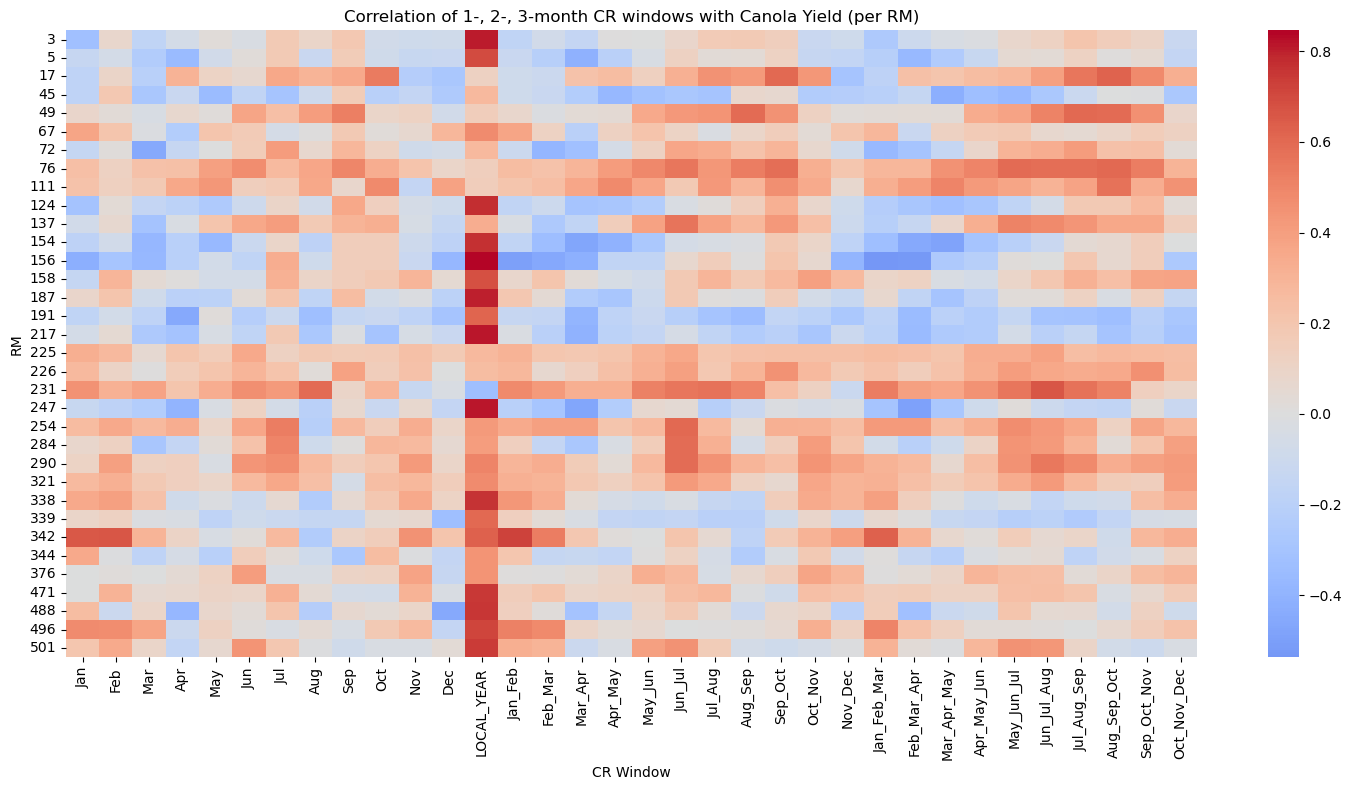

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,8))

# Heatmap of correlation matrix (RMs x CR windows)
sns.heatmap(
    corr_matrix,       # your per-RM correlation matrix
    cmap='coolwarm',   # blue-red diverging colors
    center=0,          # correlations around 0
    annot=False,       # set True to display correlation numbers in cells
    fmt=".2f"          # 2 decimal places
)

plt.title('Correlation of 1-, 2-, 3-month CR windows with Canola Yield (per RM)')
plt.xlabel('CR Window')
plt.ylabel('RM')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [36]:
# year eliminated

In [18]:
# Columns to exclude from CR selection
exclude_cols = ['RMs', 'LOCAL_YEAR', 'Canola']

# 1-month windows (explicit, safe)
cr_1m = ['Jan','Feb','Mar','Apr','May','Jun',
         'Jul','Aug','Sep','Oct','Nov','Dec']

# 2-month CR windows (exactly 1 underscore, excluding non-CR columns)
cr_2m = [
    col for col in merged.columns
    if col.count('_') == 1 and col not in exclude_cols
]

# 3-month CR windows (exactly 2 underscores)
cr_3m = [
    col for col in merged.columns
    if col.count('_') == 2
]

# Combine all CR windows
cr_1_2_3m = cr_1m + cr_2m + cr_3m

In [19]:
# --- 2. Get unique RMs ---
rm_list = merged['RMs'].unique()

# --- 3. Create empty DataFrame to store correlations ---
corr_matrix = pd.DataFrame(index=rm_list, columns=cr_1_2_3m)

# --- 4. Compute correlation per RM ---
for rm in rm_list:
    df_rm = merged[merged['RMs'] == rm]  # select one RM
    for col in cr_1_2_3m:
        if col in df_rm.columns:
            corr_matrix.loc[rm, col] = df_rm[col].corr(df_rm['Canola'])

# Convert all values to float
corr_matrix = corr_matrix.astype(float)

# --- 5. Check result ---
print(corr_matrix.head())

         Jan       Feb       Mar       Apr       May       Jun       Jul  \
3  -0.325403  0.077301 -0.166615 -0.058392  0.022264 -0.029411  0.172427   
5  -0.134277 -0.062188 -0.239301 -0.357076 -0.076234  0.021395  0.171449   
17 -0.172261  0.096177 -0.205627  0.309397  0.110827  0.064354  0.359994   
45 -0.172061  0.192389 -0.279058 -0.125471 -0.350246 -0.162406 -0.304667   
49  0.081640  0.027694 -0.037253  0.068779  0.017370  0.373887  0.244702   

         Aug       Sep       Oct  ...  Jan_Feb_Mar  Feb_Mar_Apr  Mar_Apr_May  \
3   0.090731  0.191509 -0.074041  ...    -0.257552    -0.101068    -0.038554   
5  -0.123582  0.163084 -0.078162  ...    -0.212504    -0.367054    -0.246646   
17  0.296814  0.349928  0.536777  ...    -0.180398     0.233880     0.211146   
45 -0.094183  0.162223 -0.206475  ...    -0.205044    -0.139860    -0.425678   
49  0.407016  0.523414  0.093952  ...     0.029058     0.040125     0.034381   

    Apr_May_Jun  May_Jun_Jul  Jun_Jul_Aug  Jul_Aug_Sep  Aug_Se

In [20]:
# Define output folder and file name
output_folder = "/Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/results"
output_file = os.path.join(output_folder, "3window_corr_results_without_year.csv")

# Save correlation matrix
corr_matrix.to_csv(output_file, index=True)  # keep RMs as row index

print(f"3-window correlation results saved successfully to:\n{output_file}")

3-window correlation results saved successfully to:
/Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/results/3window_corr_results_without_year.csv


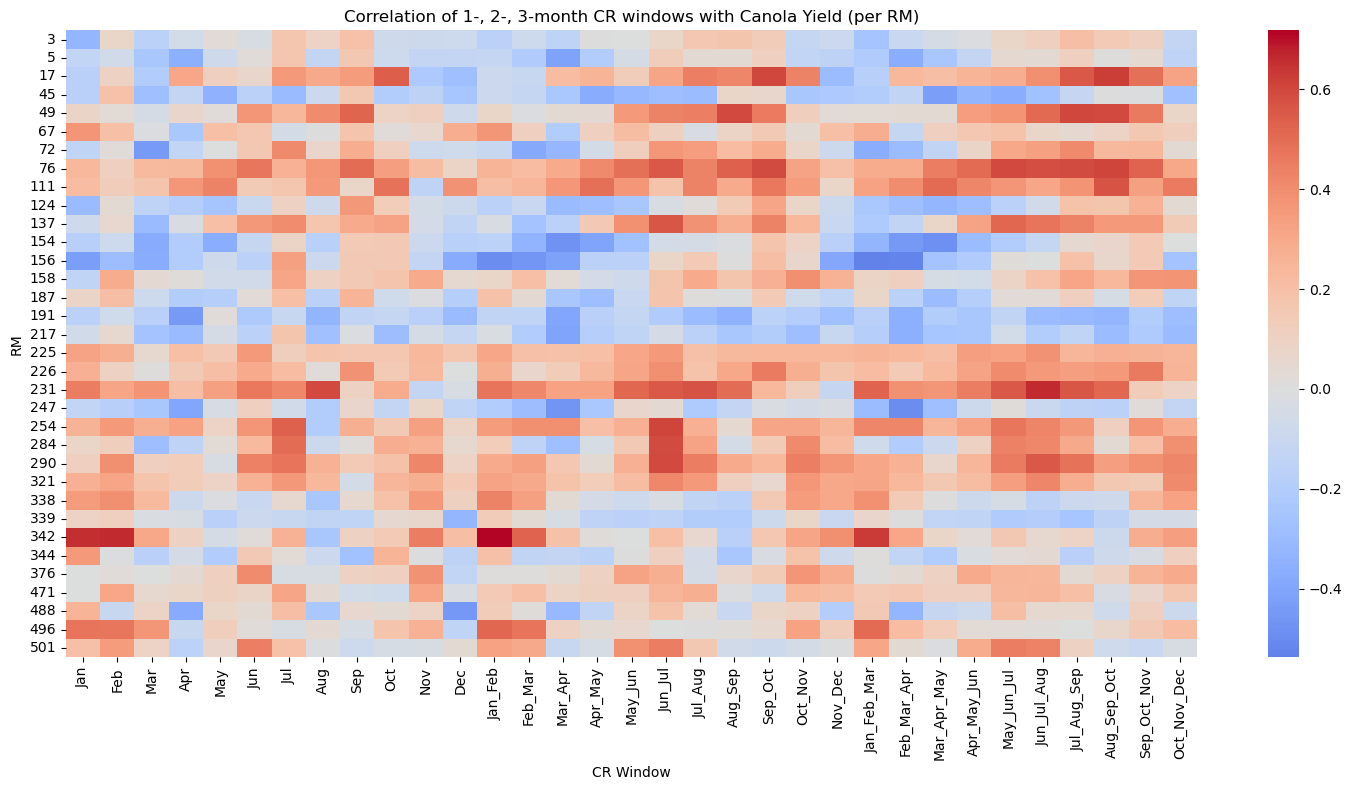

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,8))

# Heatmap of correlation matrix (RMs x CR windows)
sns.heatmap(
    corr_matrix,       # your per-RM correlation matrix
    cmap='coolwarm',   # blue-red diverging colors
    center=0,          # correlations around 0
    annot=False,       # set True to display correlation numbers in cells
    fmt=".2f"          # 2 decimal places
)

plt.title('Correlation of 1-, 2-, 3-month CR windows with Canola Yield (per RM)')
plt.xlabel('CR Window')
plt.ylabel('RM')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

lit review (agrig/finance journals) impact of precipitation(changing climate) on yield (higher yiels this is what farmer targets). Question on lit review where focus on, what period to focus on, with reference from lit. focus on growing season or not?

decide period first then caalculate K (say period is June-August) then K ave(June-August) 1995-2024) it will be scalar. K 100 mm. (suppose this is) September 2025 (buy insurance May 2025)  

test the data (out of sample testing) 

cretia that is logical and defendable, 
if we focus on high yield then we need to just why high yield. 

for the moment let us focus on growing season. 
global ag risk solutions (how they do weather derivative)

why weather derivatives are important, and different from insurance. 
find 4 or 5 RM.s and do analysis. 

# Analysis

In [22]:
# Select CR window with highest correlation per RM
best_cr = corr_matrix.idxmax(axis=1)

best_cr_df = best_cr.reset_index()
best_cr_df.columns = ['RMs', 'Best_CR']

merged_with_cr = merged.merge(best_cr_df, on='RMs', how='left')

# Construct X (CR index)
merged_with_cr['X'] = merged_with_cr.apply(
    lambda row: row[row['Best_CR']],
    axis=1
)

merged_with_cr[['RMs','LOCAL_YEAR','Best_CR','X','Canola']].head()

,RMs,LOCAL_YEAR,Best_CR,X,Canola
0,3,1995,Jul_Aug_Sep,0.0,18.8
1,3,1996,Jul_Aug_Sep,85.0,24.1
2,3,1997,Jul_Aug_Sep,141.6,16.6
3,3,1998,Jul_Aug_Sep,23.0,20.5
4,3,1999,Jul_Aug_Sep,76.0,20.3


In [23]:
K_df = (
    merged_with_cr
    .groupby('RMs')['X']
    .mean()
    .reset_index()
    .rename(columns={'X':'K'})
)

merged_with_cr = merged_with_cr.merge(K_df, on='RMs', how='left')

$$
\max(K - X_t, 0)
$$

In [24]:
merged_with_cr['Shortfall'] = (
    merged_with_cr['K'] - merged_with_cr['X']
).clip(lower=0)

In [26]:
# BASE REVENUE (NO HEDGE)
merged_with_cr['Revenue_no_ins'] = merged_with_cr['Canola']

In [27]:
# FITTED TICK SIZE V
def revenue_sd_given_V(V, revenue_no_ins, D):
    revenue_ins = revenue_no_ins + V * D
    return np.std(revenue_ins, ddof=1)

def fit_optimal_V(df_rm):
    revenue_no_ins = df_rm['Revenue_no_ins'].values
    D = df_rm['Shortfall'].values

    result = minimize_scalar(
        revenue_sd_given_V,
        bounds=(1e-6, 1e6),
        args=(revenue_no_ins, D),
        method='bounded'
    )
    return result.x

In [29]:
# Fit V per RM
optimal_V = (
    merged_with_cr
    .groupby('RMs')
    .apply(fit_optimal_V)
    .to_frame(name='V_optimal')
)

merged_with_cr = merged_with_cr.merge(
    optimal_V,
    left_on='RMs',
    right_index=True,
    how='left'
)

/var/folders/48/n8zx9ybn62v5pr7plz93n_q00000gn/T/ipykernel_22878/1272386337.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(fit_optimal_V)


In [43]:
optimal_V.to_csv(
    "/Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/results/V_hedge.csv"
)

In [42]:
# INSURANCE PAYOFF WITH FITTED V

merged_with_cr['P_insurance_fitted'] = (
    merged_with_cr['V_optimal'] * merged_with_cr['Shortfall']
)

merged_with_cr['Revenue_ins_fitted'] = (
    merged_with_cr['Revenue_no_ins']
    + merged_with_cr['P_insurance_fitted']
)

print(
    merged_with_cr[
        ['RMs', 'V_optimal', 'Shortfall', 'P_insurance_fitted', 'Revenue_ins_fitted']
    ].head()
)

   RMs  V_optimal   Shortfall  P_insurance_fitted  Revenue_ins_fitted
0    3    0.04619  105.513333            4.873608           23.673608
1    3    0.04619   20.513333            0.947501           25.047501
2    3    0.04619    0.000000            0.000000           16.600000
3    3    0.04619   82.513333            3.811250           24.311250
4    3    0.04619   29.513333            1.363206           21.663206


$$
P_t = V \cdot (K - X_t)
$$

In [31]:
# WEATHER DERIVATIVES (WITH FITTED TICK SIZE)

def revenue_sd_derivative_given_V(V, revenue_no_ins, K, X):
    """
    V: tick size (scalar, strictly positive)
    revenue_no_ins: R_t without hedge
    K: strike (scalar)
    X: realized CR index
    """
    payoff = V * (K - X)
    revenue_deriv = revenue_no_ins + payoff
    return np.std(revenue_deriv, ddof=1)

In [32]:
# Fit optimal derivative tick size per RM

def fit_optimal_V_derivative(df_rm):
    revenue_no_ins = df_rm['Revenue_no_ins'].values
    X = df_rm['X'].values
    K = df_rm['K'].iloc[0]  # constant per RM

    result = minimize_scalar(
        revenue_sd_derivative_given_V,
        bounds=(1e-6, 1e6),
        args=(revenue_no_ins, K, X),
        method='bounded'
    )
    return result.x

In [33]:
# Estimate RM-specific derivative tick sizes

optimal_V_deriv = (
    merged_with_cr
    .groupby('RMs')
    .apply(fit_optimal_V_derivative)
    .to_frame(name='V_derivative_optimal')
)

merged_with_cr = merged_with_cr.merge(
    optimal_V_deriv,
    left_on='RMs',
    right_index=True,
    how='left'
)

print(optimal_V_deriv.head())

     V_derivative_optimal
RMs                      
3                0.023193
5                0.035491
17               0.099798
45               0.223249
49               0.091545


/var/folders/48/n8zx9ybn62v5pr7plz93n_q00000gn/T/ipykernel_22878/1867115355.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(fit_optimal_V_derivative)


In [44]:
# Derivative payoff & revenue (fitted V)

merged_with_cr['P_derivative_fitted'] = (
    merged_with_cr['V_derivative_optimal']
    * (merged_with_cr['K'] - merged_with_cr['X'])
)

merged_with_cr['Revenue_deriv_fitted'] = (
    merged_with_cr['Revenue_no_ins']
    + merged_with_cr['P_derivative_fitted']
)

print(
    merged_with_cr[
        ['RMs', 'V_derivative_optimal', 'K', 'X',
         'P_derivative_fitted', 'Revenue_deriv_fitted']
    ].head()
)


   RMs  V_derivative_optimal           K      X  P_derivative_fitted  \
0    3              0.023193  105.513333    0.0             2.447172   
1    3              0.023193  105.513333   85.0             0.475766   
2    3              0.023193  105.513333  141.6            -0.836958   
3    3              0.023193  105.513333   23.0             1.913732   
4    3              0.023193  105.513333   76.0             0.684503   

   Revenue_deriv_fitted  
0             21.247172  
1             24.575766  
2             15.763042  
3             22.413732  
4             20.984503  


In [36]:
# SD and VaR (insurance)
def compute_risk_metrics(series):
    mean_val = series.mean()
    sd = series.std(ddof=1)
    var_95 = np.percentile(series, 5)
    var_90 = np.percentile(series, 10)
    return pd.Series({
        'Mean': mean_val,
        'SD': sd,
        'VaR_95': var_95,
        'VaR_90': var_90
    })

In [37]:
# RISK METRICS

risk_no_ins = merged_with_cr.groupby('RMs').apply(
    lambda x: compute_risk_metrics(x['Revenue_no_ins'])
)

risk_ins_fitted = merged_with_cr.groupby('RMs').apply(
    lambda x: compute_risk_metrics(x['Revenue_ins_fitted'])
)

risk_deriv_fitted = merged_with_cr.groupby('RMs').apply(
    lambda x: compute_risk_metrics(x['Revenue_deriv_fitted'])
)

/var/folders/48/n8zx9ybn62v5pr7plz93n_q00000gn/T/ipykernel_22878/1080570522.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  risk_no_ins = merged_with_cr.groupby('RMs').apply(
/var/folders/48/n8zx9ybn62v5pr7plz93n_q00000gn/T/ipykernel_22878/1080570522.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  risk_ins_fitted = merged_with_cr.groupby('RMs').apply(
/var/folders/48/n8zx9ybn62v5pr7plz93n_q00000gn/T

In [45]:
# RISK REDUCTION (INSURANCE, FITTED V)

insurance_comparison = risk_no_ins.join(
    risk_ins_fitted,
    lsuffix='_NoHedge',
    rsuffix='_Insurance'
)

insurance_comparison['SD_Reduction_%'] = (
    (insurance_comparison['SD_NoHedge'] - insurance_comparison['SD_Insurance'])
    / insurance_comparison['SD_NoHedge']
) * 100

insurance_comparison['VaR95_Reduction_%'] = (
    (insurance_comparison['VaR_95_NoHedge'] - insurance_comparison['VaR_95_Insurance'])
    / insurance_comparison['VaR_95_NoHedge']
) * 100

insurance_comparison['VaR90_Reduction_%'] = (
    (insurance_comparison['VaR_90_NoHedge'] - insurance_comparison['VaR_90_Insurance'])
    / insurance_comparison['VaR_90_NoHedge']
) * 100

insurance_comparison.to_csv(
    "/Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/results/insurance_risk_reduction_fittedV.csv"
)

In [46]:
# RISK REDUCTION (DERIVATIVES, FITTED V)

derivative_comparison = risk_no_ins.join(
    risk_deriv_fitted,
    lsuffix='_NoHedge',
    rsuffix='_Derivative'
)

derivative_comparison['SD_Reduction_%'] = (
    (derivative_comparison['SD_NoHedge'] - derivative_comparison['SD_Derivative'])
    / derivative_comparison['SD_NoHedge']
) * 100

derivative_comparison['VaR95_Reduction_%'] = (
    (derivative_comparison['VaR_95_NoHedge'] - derivative_comparison['VaR_95_Derivative'])
    / derivative_comparison['VaR_95_NoHedge']
) * 100

derivative_comparison['VaR90_Reduction_%'] = (
    (derivative_comparison['VaR_90_NoHedge'] - derivative_comparison['VaR_90_Derivative'])
    / derivative_comparison['VaR_90_NoHedge']
) * 100

derivative_comparison.to_csv(
    "/Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/results/derivative_risk_reduction_fittedV.csv"
)

In [47]:
# SHARPE RATIOS

def sharpe_ratio(series):
    return series.mean() / series.std(ddof=1)

# Insurance Sharpe (fitted V)
sharpe_insurance = merged_with_cr.groupby('RMs').apply(
    lambda x: pd.Series({
        'Sharpe_NoHedge': sharpe_ratio(x['Revenue_no_ins']),
        'Sharpe_Insurance': sharpe_ratio(x['Revenue_ins_fitted'])
    })
)

# Derivative Sharpe (fitted V)
sharpe_derivative = merged_with_cr.groupby('RMs').apply(
    lambda x: pd.Series({
        'Sharpe_NoHedge': sharpe_ratio(x['Revenue_no_ins']),
        'Sharpe_Derivative': sharpe_ratio(x['Revenue_deriv_fitted'])
    })
)

sharpe_insurance.to_csv(
    "/Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/results/sharpe_insurance_fittedV.csv"
)

sharpe_derivative.to_csv(
    "/Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/results/sharpe_derivative_fittedV.csv"
)

/var/folders/48/n8zx9ybn62v5pr7plz93n_q00000gn/T/ipykernel_22878/1475255979.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sharpe_insurance = merged_with_cr.groupby('RMs').apply(
/var/folders/48/n8zx9ybn62v5pr7plz93n_q00000gn/T/ipykernel_22878/1475255979.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sharpe_derivative = merged_with_cr.groupby('RMs').apply(


# Calculate ave Var_reducation, also IQR for VAR_reduction. 
# Percentage change in sharp ratio to be able tosee the net improment 
 agricultural finance review  journal check their requirments. 

# Analysis

In [22]:
# Select CR window with highest correlation per RM
best_cr = corr_matrix.idxmax(axis=1)

# Convert to DataFrame
best_cr_df = best_cr.reset_index()
best_cr_df.columns = ['RMs', 'Best_CR']

print(best_cr_df.head())

   RMs      Best_CR
0    3  Jul_Aug_Sep
1    5          Jul
2   17  Aug_Sep_Oct
3   45          Feb
4   49  Jul_Aug_Sep


In [23]:
merged_with_cr = merged.merge(best_cr_df, on='RMs', how='left')

# Create X (CR index) column
merged_with_cr['X'] = merged_with_cr.apply(
    lambda row: row[row['Best_CR']],
    axis=1
)

print(merged_with_cr[['RMs','LOCAL_YEAR','Best_CR','X','Canola']].head())


   RMs  LOCAL_YEAR      Best_CR      X  Canola
0    3        1995  Jul_Aug_Sep    0.0    18.8
1    3        1996  Jul_Aug_Sep   85.0    24.1
2    3        1997  Jul_Aug_Sep  141.6    16.6
3    3        1998  Jul_Aug_Sep   23.0    20.5
4    3        1999  Jul_Aug_Sep   76.0    20.3


# WEATHER INDEX-BASED INSURANCE

In [24]:
K_df = (
    merged_with_cr
    .groupby('RMs')['X']
    .mean()
    .reset_index()
    .rename(columns={'X':'K'})
)

merged_with_cr = merged_with_cr.merge(K_df, on='RMs', how='left')

print(merged_with_cr[['RMs','X','K']].head())

   RMs      X           K
0    3    0.0  105.513333
1    3   85.0  105.513333
2    3  141.6  105.513333
3    3   23.0  105.513333
4    3   76.0  105.513333


In [25]:
V = 1 # tick size (constant, set a priori)
# Insurance payoff (Equation 2)
merged_with_cr['P_insurance'] = V * np.maximum(
    merged_with_cr['K'] - merged_with_cr['X'],
    0
)

print(merged_with_cr[['X','K','P_insurance']].head())

       X           K  P_insurance
0    0.0  105.513333   105.513333
1   85.0  105.513333    20.513333
2  141.6  105.513333     0.000000
3   23.0  105.513333    82.513333
4   76.0  105.513333    29.513333


In [26]:
# Fair premium (expected payoff)
premium_df = (
    merged_with_cr
    .groupby('RMs')['P_insurance']
    .mean()
    .reset_index()
    .rename(columns={'P_insurance':'Premium'})
)

merged_with_cr = merged_with_cr.merge(premium_df, on='RMs', how='left')

print(merged_with_cr[['RMs','Premium']].drop_duplicates().head())

    RMs    Premium
0     3  23.496667
30    5  15.000000
60   17  19.334921
81   45   3.311765
98   49  21.168038


In [27]:
# Revenue with insurance
merged_with_cr['Revenue_no_ins'] = merged_with_cr['Canola']

merged_with_cr['Revenue_ins'] = (
    merged_with_cr['Revenue_no_ins']
    + merged_with_cr['P_insurance']
)

In [28]:
# SD and VaR (insurance)
def compute_risk_metrics(series):
    mean_val = series.mean()
    sd = series.std(ddof=1)
    var_95 = np.percentile(series, 5)
    var_90 = np.percentile(series, 10)
    return pd.Series({
        'Mean': mean_val,
        'SD': sd,
        'VaR_95': var_95,
        'VaR_90': var_90
    })

risk_no_ins = (
    merged_with_cr
    .groupby('RMs')
    .apply(lambda x: compute_risk_metrics(x['Revenue_no_ins']))
)

risk_ins = (
    merged_with_cr
    .groupby('RMs')
    .apply(lambda x: compute_risk_metrics(x['Revenue_ins']))
)

/var/folders/48/n8zx9ybn62v5pr7plz93n_q00000gn/T/ipykernel_20106/3193894239.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: compute_risk_metrics(x['Revenue_no_ins']))
/var/folders/48/n8zx9ybn62v5pr7plz93n_q00000gn/T/ipykernel_20106/3193894239.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: compute_risk_metrics(x['Revenue_ins']))


# Fitted tick size

In [29]:
def revenue_sd_given_V(V, revenue_no_ins, D):
    """
    V: tick size (scalar, strictly positive)
    revenue_no_ins: array-like, R_t without insurance
    D: array-like, max(K - X_t, 0)
    """
    revenue_ins = revenue_no_ins + V * D
    return np.std(revenue_ins, ddof=1)

In [30]:
def fit_optimal_V(df_rm):
    revenue_no_ins = df_rm['Revenue_no_ins'].values
    D = df_rm['Shortfall'].values  # Shortfall = max(K - X, 0)

    result = minimize_scalar(
        revenue_sd_given_V,
        bounds=(1e-6, 1e6),   # V strictly positive
        args=(revenue_no_ins, D),
        method='bounded'
    )

    return result.x

In [31]:
# Shortfall
merged_with_cr['Shortfall'] = (
    merged_with_cr['K'] - merged_with_cr['X']
).clip(lower=0)

In [32]:
optimal_V = (
    merged_with_cr
    .groupby('RMs')
    .apply(fit_optimal_V)
    .to_frame(name='V_optimal')
)

print(optimal_V.head()) 

     V_optimal
RMs           
3     0.046190
5     0.035530
17    0.188678
45    0.274104
49    0.142868


/var/folders/48/n8zx9ybn62v5pr7plz93n_q00000gn/T/ipykernel_20106/3083064824.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(fit_optimal_V)


In [33]:
# Assuming optimal_V is already created
tick_size_path = "/Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/results/tick_size.csv"
# Save to CSV
optimal_V.to_csv(tick_size_path)
print(f"Saved optimal_V as tick_size.csv at {tick_size_path}")

Saved optimal_V as tick_size.csv at /Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/results/tick_size.csv


In [34]:
merged_with_cr = merged_with_cr.merge(
    optimal_V,
    left_on='RMs',
    right_index=True,
    how='left'
)

merged_with_cr['Revenue_ins_fittedV'] = (
    merged_with_cr['Revenue_no_ins']
    + merged_with_cr['V_optimal'] * merged_with_cr['Shortfall']
)

# WEATHER DERIVATIVES

In [73]:
# Derivative payoff (Equation 3)
merged_with_cr['P_derivative'] = V * (
    merged_with_cr['K'] - merged_with_cr['X']
)

In [74]:
# Revenue with derivative hedge
merged_with_cr['Revenue_deriv'] = (
    merged_with_cr['Revenue_no_ins']
    + merged_with_cr['P_derivative']
)


In [75]:
# SD and VaR (derivative)
risk_deriv = (
    merged_with_cr
    .groupby('RMs')
    .apply(lambda x: compute_risk_metrics(x['Revenue_deriv']))
)

/var/folders/48/n8zx9ybn62v5pr7plz93n_q00000gn/T/ipykernel_52316/1258876430.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: compute_risk_metrics(x['Revenue_deriv']))


### Risk Reduction Formula

$$
\text{Risk Reduction (\%)} =
\frac{\text{Risk}_{\text{Hedge}} - \text{Risk}_{\text{No Hedged}}}
{\text{Risk}_{\text{No Hedge}}}
\times 100
$$


# Insurance risk-reduction (%)

In [76]:
# Combine no-hedge and insurance risk metrics
insurance_comparison = risk_no_ins.join(
    risk_ins,
    lsuffix='_NoHedge',
    rsuffix='_Insurance'
)

# Risk reduction percentages
insurance_comparison['SD_Reduction_%'] = (
    (insurance_comparison['SD_NoHedge'] - insurance_comparison['SD_Insurance'])
    / insurance_comparison['SD_NoHedge']
) * 100

insurance_comparison['VaR95_Reduction_%'] = (
    (insurance_comparison['VaR_95_NoHedge'] - insurance_comparison['VaR_95_Insurance'])
    / insurance_comparison['VaR_95_NoHedge']
) * 100

insurance_comparison['VaR90_Reduction_%'] = (
    (insurance_comparison['VaR_90_NoHedge'] - insurance_comparison['VaR_90_Insurance'])
    / insurance_comparison['VaR_90_NoHedge']
) * 100

print(insurance_comparison.head())


     Mean_NoHedge  SD_NoHedge  VaR_95_NoHedge  VaR_90_NoHedge  Mean_Insurance  \
RMs                                                                             
3       26.981000    7.285477          17.590           19.25       50.477667   
5       25.214667    7.555830          14.165           16.81       40.214667   
17      24.130952    8.429096          14.000           15.00       43.465873   
49      21.539630    7.657125          11.890           12.10       42.707668   
67      25.833333    7.472310          11.785           18.48       30.046000   

     SD_Insurance  VaR_95_Insurance  VaR_90_Insurance  SD_Reduction_%  \
RMs                                                                     
3       29.193686         19.390000         20.040000     -300.710726   
5       20.774442         15.970000         17.813333     -174.945877   
17      20.286752         20.695238         23.000000     -140.675301   
49      22.446770         18.640000         22.100000     -193.1488

In [71]:
# Define output path
output_dir = "/Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/results/"
os.makedirs(output_dir, exist_ok=True)

# File name
output_path = os.path.join(output_dir, "insurance_comparison.csv")

# Save
insurance_comparison.to_csv(output_path, index=True)

print("Insurance comparison results saved to:")
print(output_path)

Insurance comparison results saved to:
/Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/results/insurance_comparison.csv


# Derivative risk-reduction (%)

In [57]:
# Combine no-hedge and derivative risk metrics
derivative_comparison = risk_no_ins.join(
    risk_deriv,
    lsuffix='_NoHedge',
    rsuffix='_Derivative'
)

# Risk reduction percentages
derivative_comparison['SD_Reduction_%'] = (
    (derivative_comparison['SD_NoHedge'] - derivative_comparison['SD_Derivative'])
    / derivative_comparison['SD_NoHedge']
) * 100

derivative_comparison['VaR95_Reduction_%'] = (
    (derivative_comparison['VaR_95_NoHedge'] - derivative_comparison['VaR_95_Derivative'])
    / derivative_comparison['VaR_95_NoHedge']
) * 100

derivative_comparison['VaR90_Reduction_%'] = (
    (derivative_comparison['VaR_90_NoHedge'] - derivative_comparison['VaR_90_Derivative'])
    / derivative_comparison['VaR_90_NoHedge']
) * 100

print(derivative_comparison.head())


     Mean_NoHedge  SD_NoHedge  VaR_95_NoHedge  VaR_90_NoHedge  \
RMs                                                             
3       26.981000    7.285477        9.391000        7.731000   
5       25.214667    7.555830       11.049667        8.404667   
17      24.130952    8.429096       10.130952        9.130952   
49      21.539630    7.657125        9.649630        9.439630   
67      25.833333    7.472310       14.048333        7.353333   

     Mean_Derivative  SD_Derivative  VaR_95_Derivative  VaR_90_Derivative  \
RMs                                                                         
3          26.981000      64.808514         116.487667          87.601667   
5          25.214667      35.984435          57.086333          50.991333   
17         24.130952      47.743031          72.235714          66.735714   
49         21.539630      46.064121          81.699815          61.664815   
67         25.833333      10.194050          19.343333          16.086333   

    

In [63]:
# Define output path
output_dir = "/Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/results/"
os.makedirs(output_dir, exist_ok=True)

# File name
output_path = os.path.join(output_dir, "derivative_comparison.csv")

# Save
derivative_comparison.to_csv(output_path, index=True)

print("Derivative comparison results saved to:")
print(output_path)

Derivative comparison results saved to:
/Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/results/derivative_comparison.csv



$$
\text{Sharpe} = \frac{\mathbb{E}(R)}{\sigma(R)}
$$


# Insurance Sharpe ratios

In [59]:
def sharpe_ratio(series):
    return series.mean() / series.std(ddof=1)

sharpe_insurance = (
    merged_with_cr
    .groupby('RMs')
    .apply(lambda x: pd.Series({
        'Sharpe_NoHedge': sharpe_ratio(x['Revenue_no_ins']),
        'Sharpe_Insurance': sharpe_ratio(x['Revenue_ins'])
    }))
)

print(sharpe_insurance.head())

     Sharpe_NoHedge  Sharpe_Insurance
RMs                                  
3          3.703395          1.729061
5          3.337114          1.935776
17         2.862816          2.142574
49         2.813018          1.902620
67         3.457208          4.303191


/var/folders/48/n8zx9ybn62v5pr7plz93n_q00000gn/T/ipykernel_52316/3006103801.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


In [64]:
# Define output path
output_dir = "/Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/results/"
os.makedirs(output_dir, exist_ok=True)

# File name
output_path = os.path.join(output_dir, "sharpe_insurance.csv")

# Save
sharpe_insurance.to_csv(output_path, index=True)

print("Sharpe ratios (insurance) saved to:")
print(output_path)

Sharpe ratios (insurance) saved to:
/Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/results/sharpe_insurance.csv


# Derivative Sharpe ratios

In [61]:
sharpe_derivative = (
    merged_with_cr
    .groupby('RMs')
    .apply(lambda x: pd.Series({
        'Sharpe_NoHedge': sharpe_ratio(x['Revenue_no_ins']),
        'Sharpe_Derivative': sharpe_ratio(x['Revenue_deriv'])
    }))
)

print(sharpe_derivative.head())


     Sharpe_NoHedge  Sharpe_Derivative
RMs                                   
3          3.703395           0.416319
5          3.337114           0.700710
17         2.862816           0.505434
49         2.813018           0.467601
67         3.457208           2.534158


/var/folders/48/n8zx9ybn62v5pr7plz93n_q00000gn/T/ipykernel_52316/1707248017.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


In [65]:
# Define output path
output_dir = "/Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/results/"
os.makedirs(output_dir, exist_ok=True)

# File name
output_path = os.path.join(output_dir, "sharpe_derivative.csv")

# Save
sharpe_derivative.to_csv(output_path, index=True)

print("Sharpe ratios (derivative) saved to:")
print(output_path)


Sharpe ratios (derivative) saved to:
/Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/results/sharpe_derivative.csv
